🔒 Random seed telah dikunci di angka 42. Hasil eksekusi akan selalu sama!

[STEP 1] Loading Pre-trained IndoNLGTokenizer...
----------------------------------------
Subjek        : SUB4
Kalimat Target: hasilnya sedikit mengejutkan
Shape Matriks : (555, 14) (Time x Channels)

VISUALISASI TOKENISASI INDOGPT
Teks Asli        : 'hasilnya sedikit mengejutkan'
Sub-Word Asli ID : [3571, 1367, 9707]
Shifted ID (+1)  : [3572, 1368, 9708]
Pemetaan Balik   : [' hasilnya', ' sedikit', ' mengejutkan']
Teks Gabungan    : 'hasilnya sedikit mengejutkan'



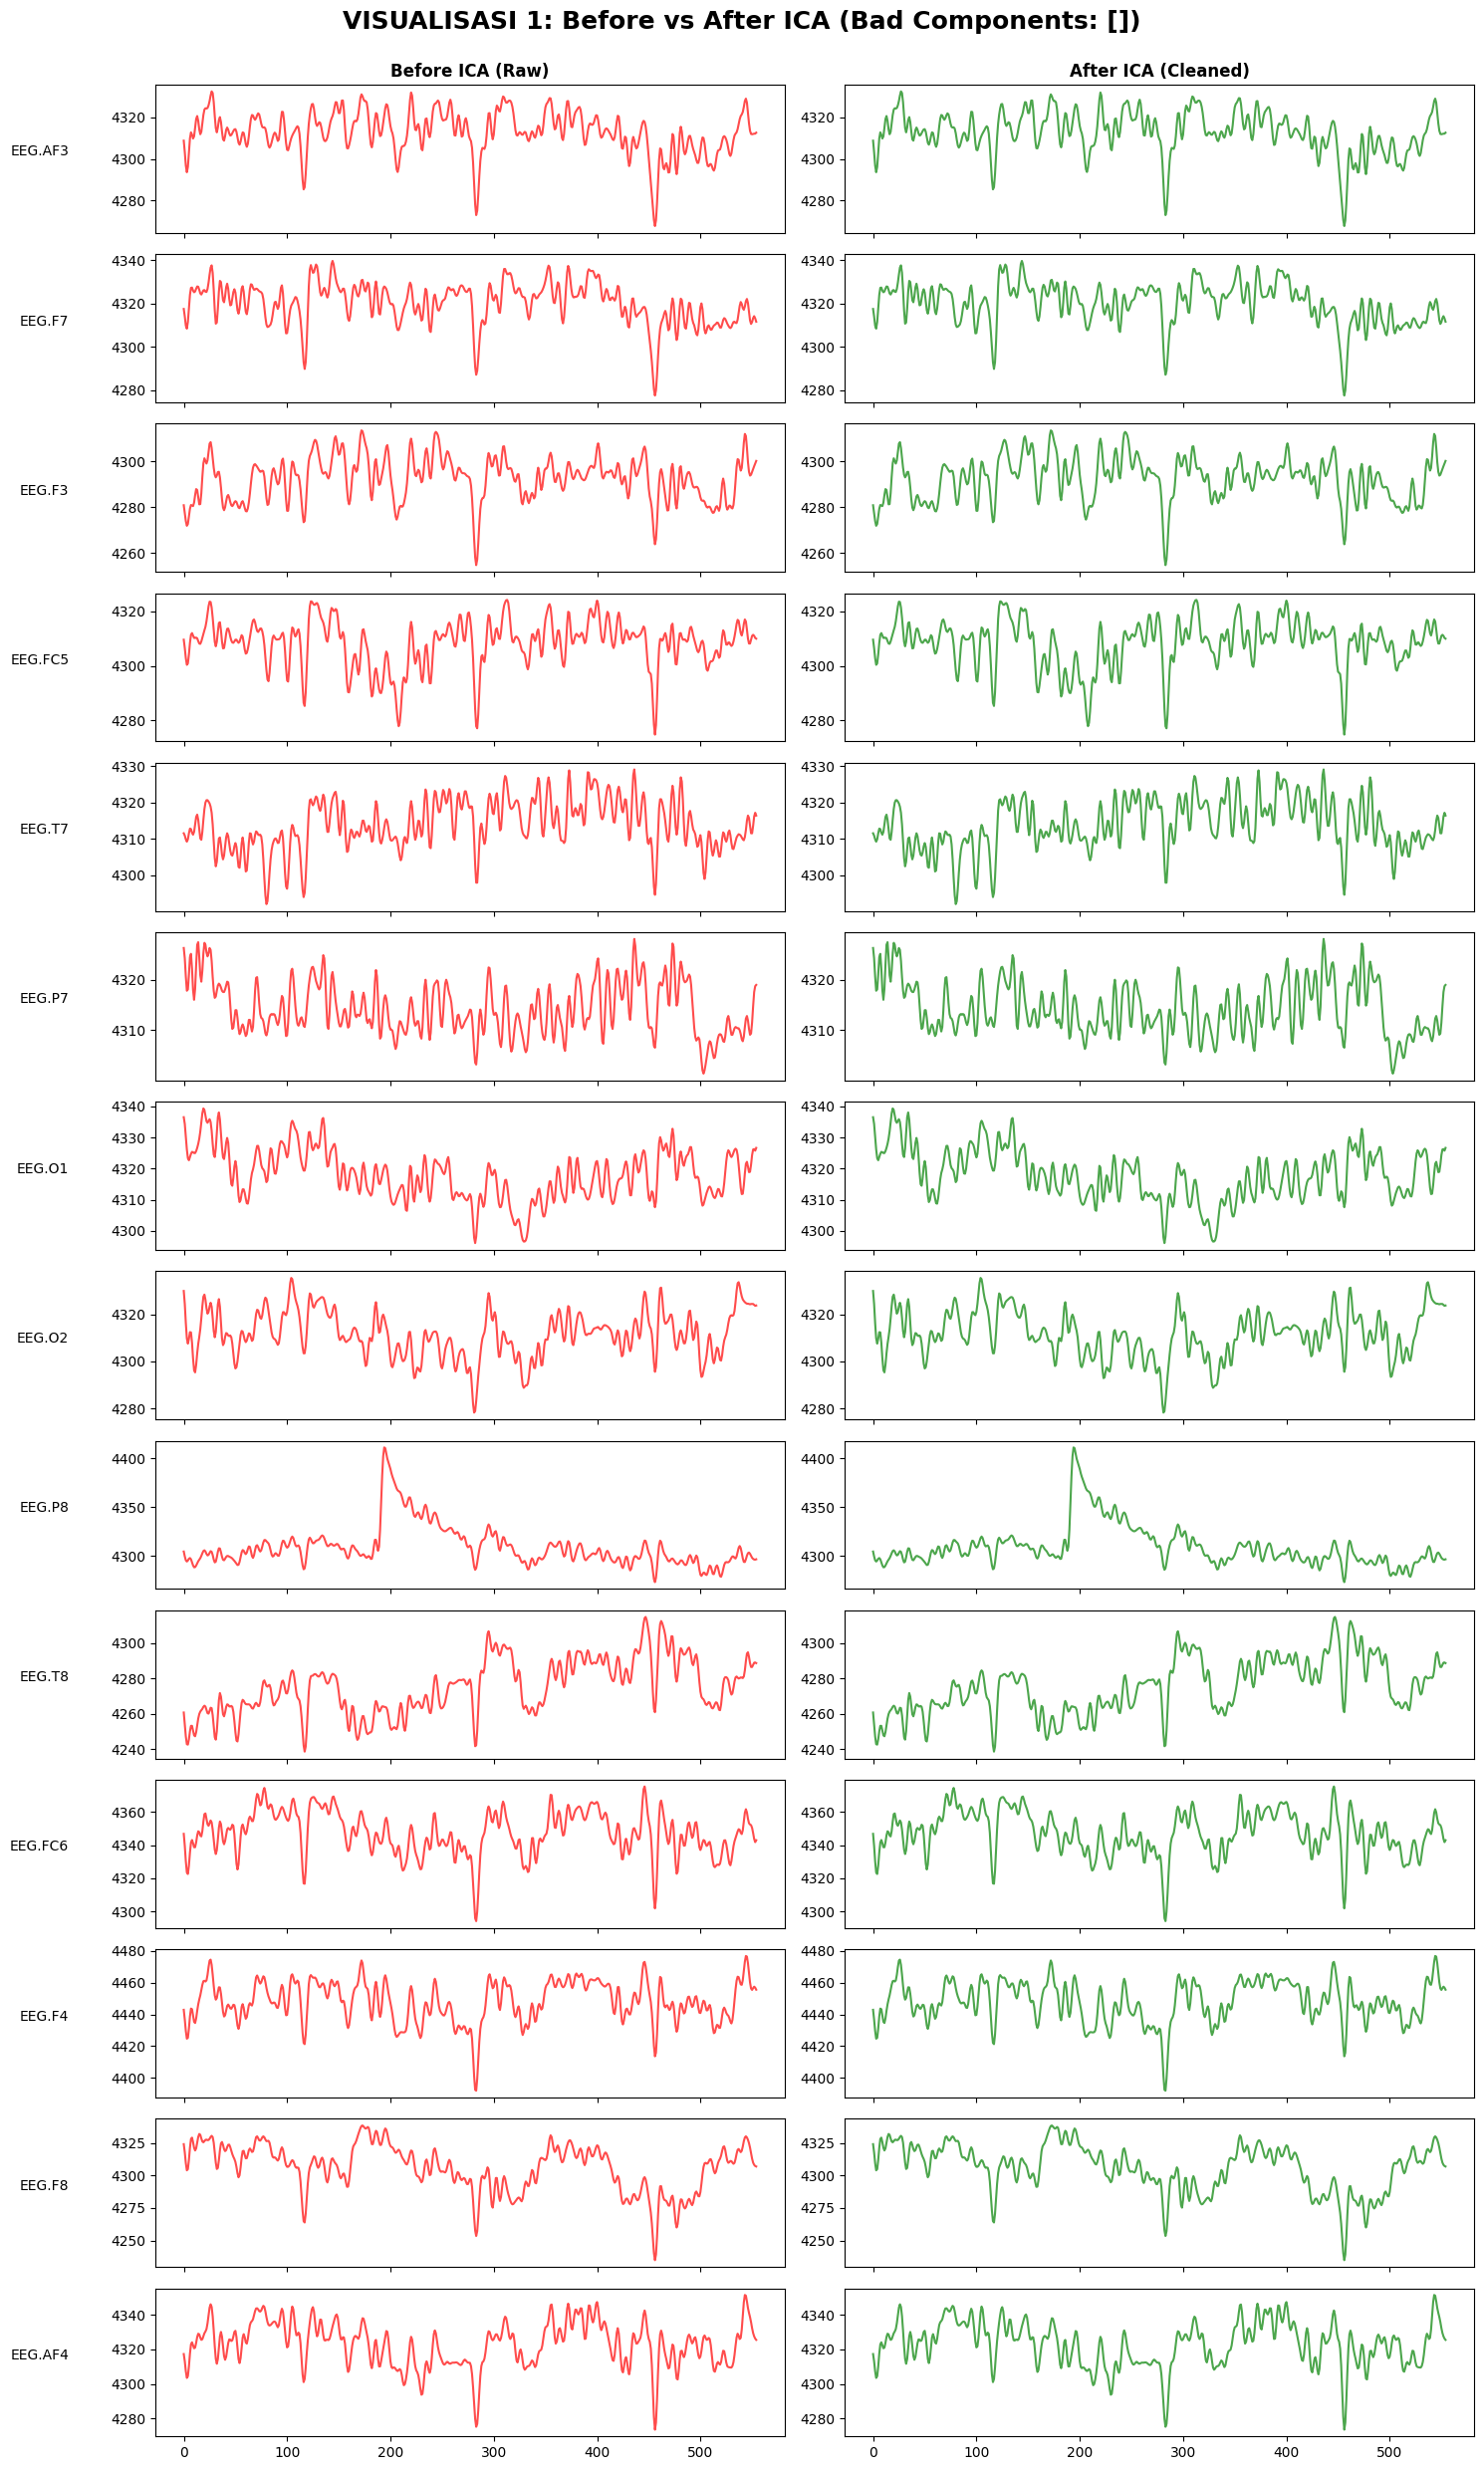


Memproses ekstraksi Log-Mel Spectrogram... Mohon tunggu.
Shape Fitur Akhir (T_Frames, 14 Ch * 64 Mels): (35, 896)


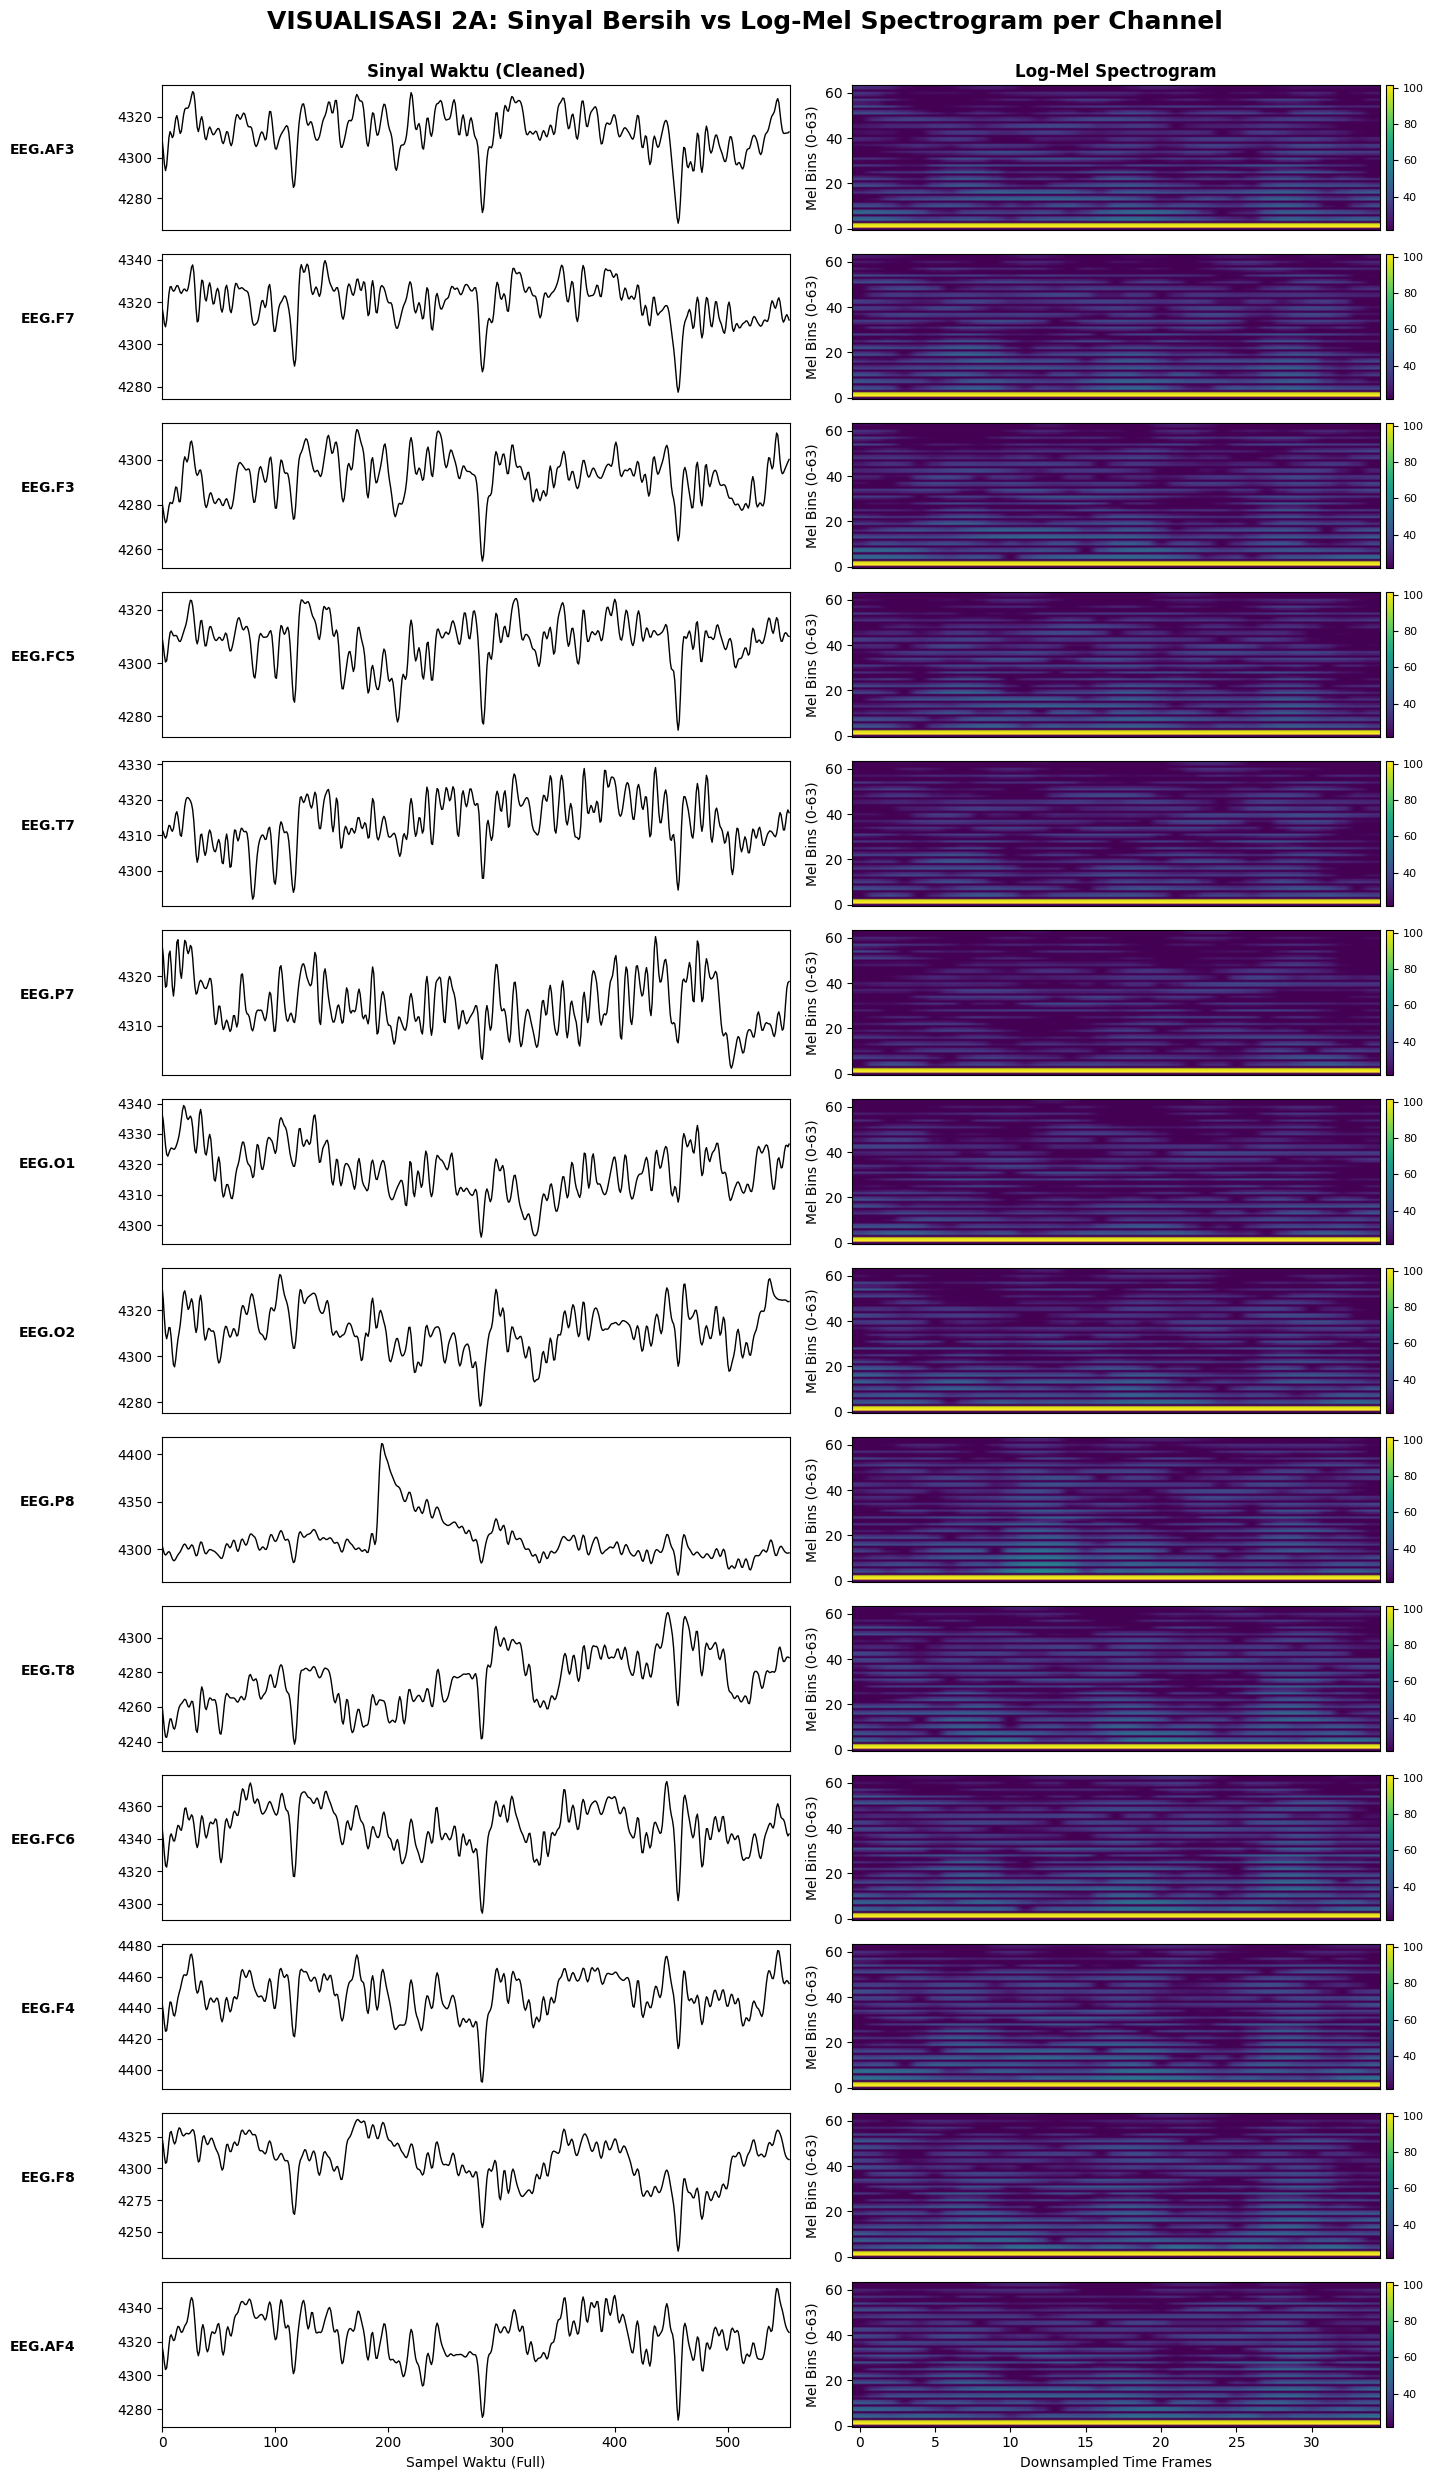

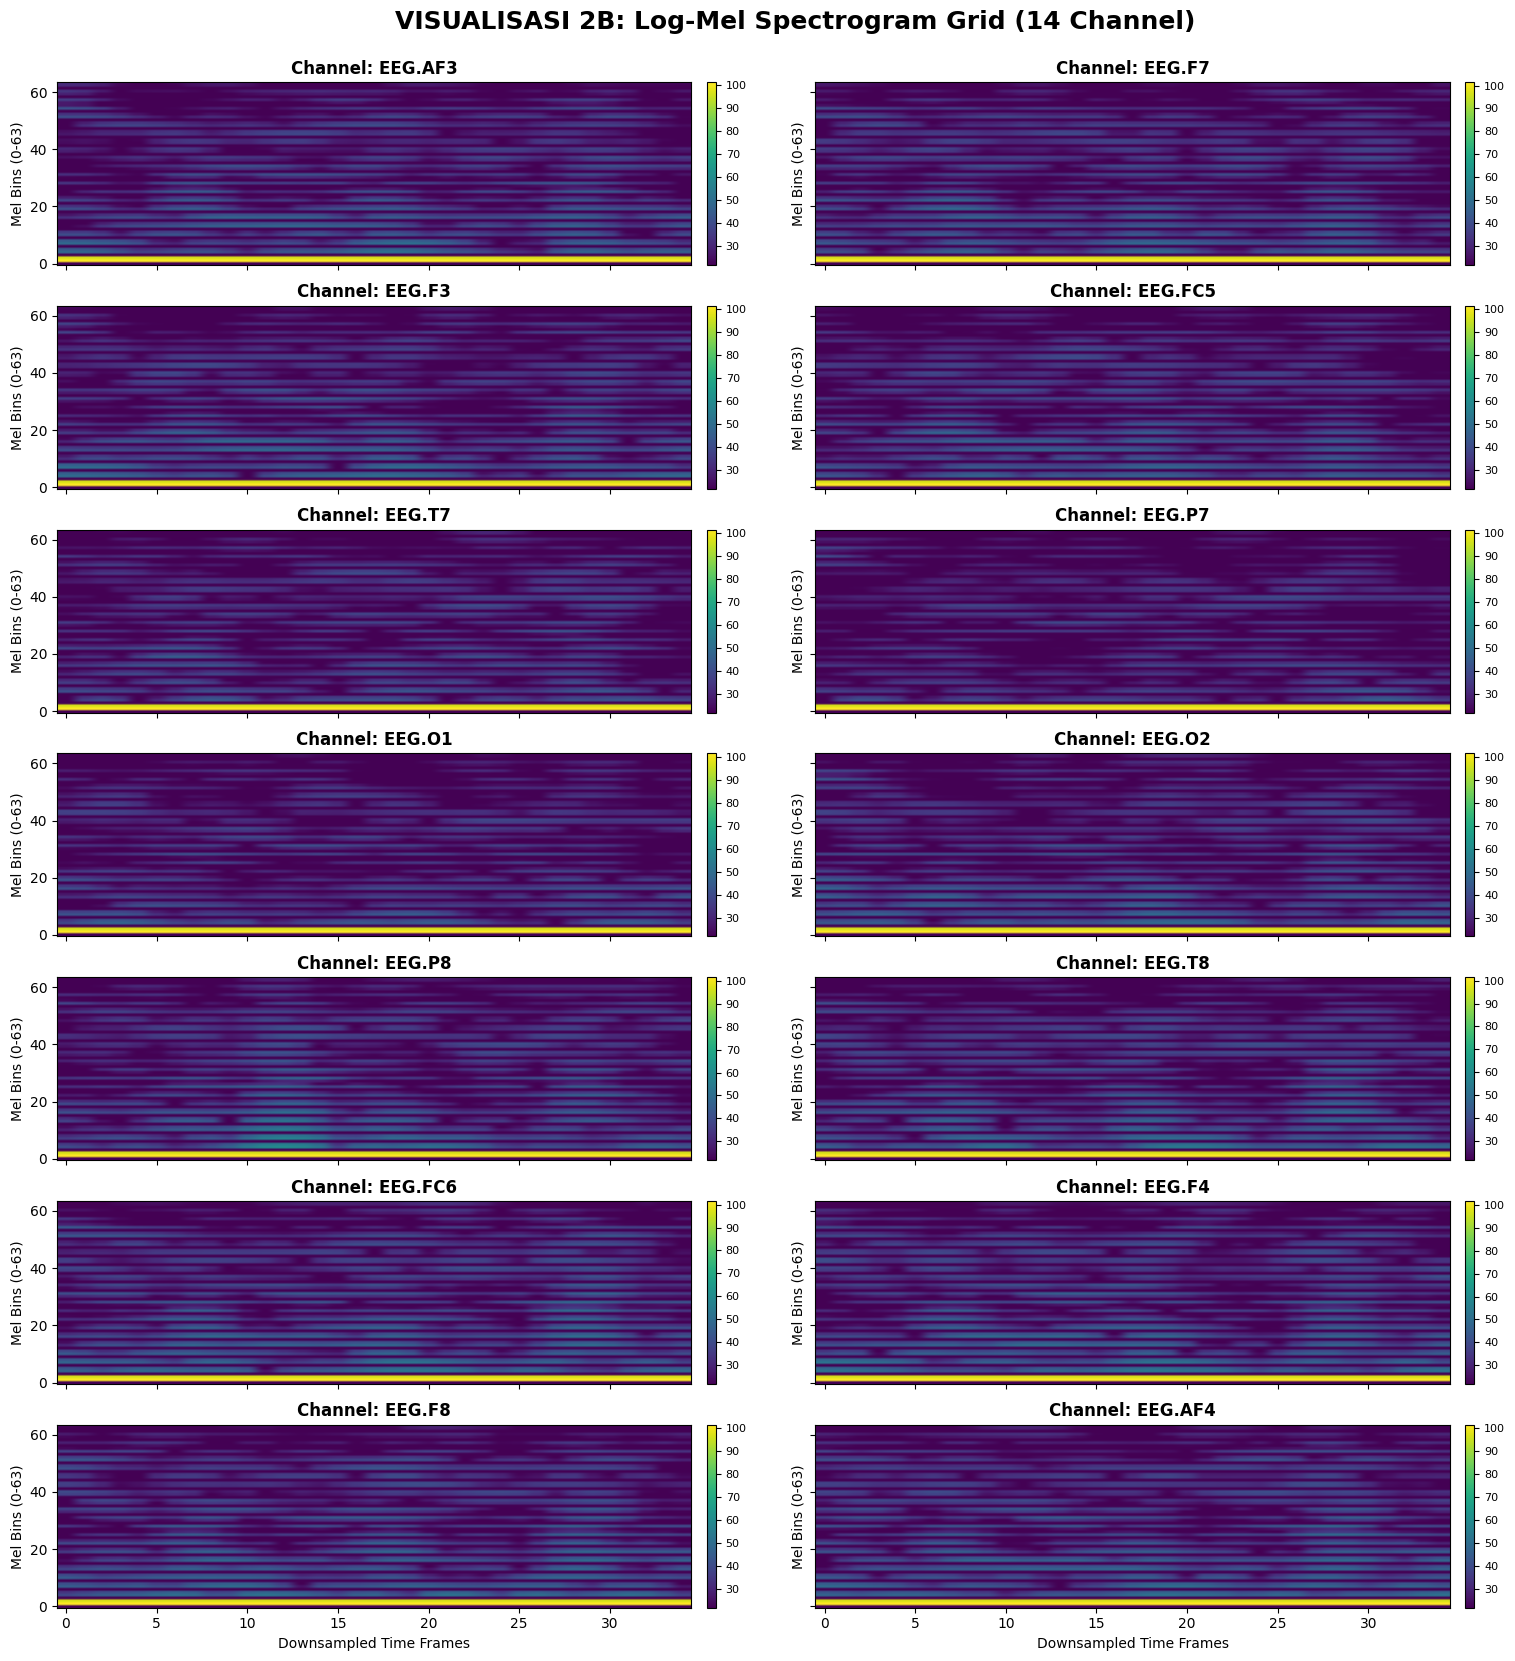

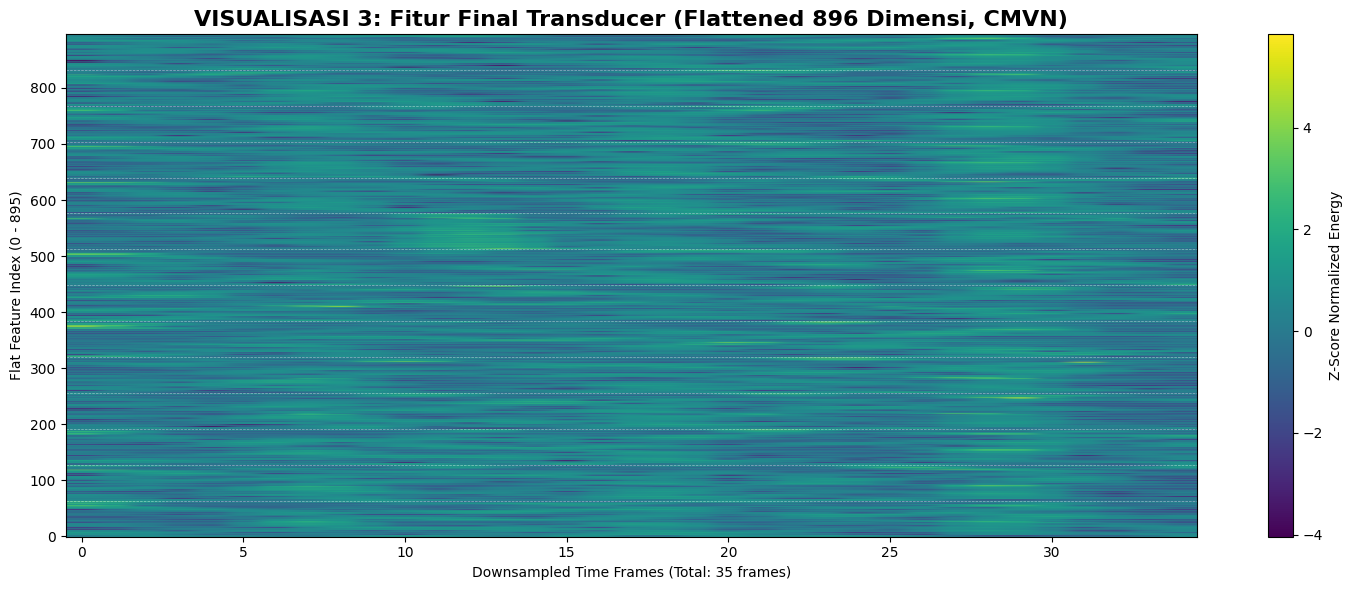


Memuat model dari SUB4_eq_3_0_logmel_best_model_10_1_IndoGPT.pt...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: indobenchmark/indogpt
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model berhasil dimuat!

Memulai proses decoding IndoGPT (Beam Search k=3)...
--------------------------------------------------
[Frame 008/9] Prediksi: hasilnya sedikit mengejutkan                      
--------------------------------------------------
Hasil Akhir  : 'hasilnya sedikit mengejutkan'
Ground Truth : 'hasilnya sedikit mengejutkan'

Mengintip 3 Semesta Teratas secara Autoregressive:
Step 01 (T=000) | S-1: '<blank>' (-3.1)  |  S-2: 'hasilnya' (-3.7)  |  S-3: 'anda' (-4.1)  |  
Step 02 (T=001) | S-1: 'hasilnya' (-5.8)  |  S-2: 'anda' (-6.5)  |  S-3: 'hasilnya sedikit mengejutkan' (-7.1)  |  
Step 03 (T=002) | S-1: 'hasilnya sedikit mengejutkan' (-7.1)  |  S-2: 'hasilnya' (-8.1)  |  S-3: 'anda' (-9.1)  |  
Step 04 (T=003) | S-1: 'hasilnya sedikit mengejutkan' (-7.1)  |  S-2: 'hasilnya' (-10.7)  |  S-3: 'anda' (-11.9)  |  
Step 05 (T=004) | S-1: 'hasilnya sedikit mengejutkan' (-7.1)  |  S-2: 'hasilnya' (-13.3)  |  S-3: 'anda' (-14.6)  |  
Step 06 (T=005) | S-1: 'hasilnya sedi

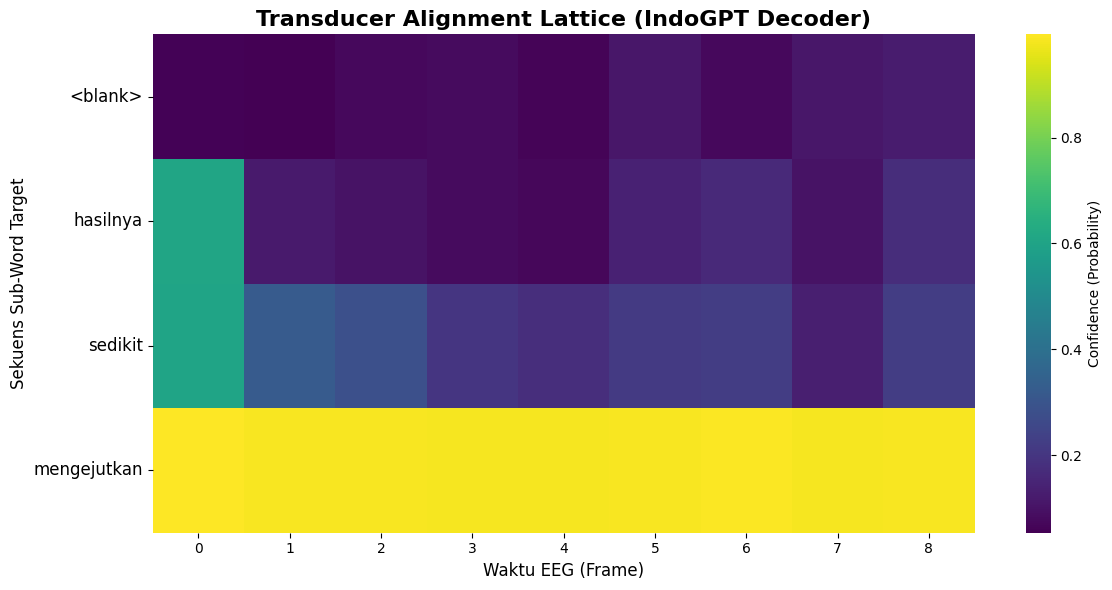

In [6]:
import os
import sys
import time
import random
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

import torchaudio.transforms as T
from sklearn.decomposition import FastICA
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. BYPASS HUGGINGFACE UNTUK INDOBENCHMARK
# ==============================================================================
import transformers.utils
import transformers.utils.generic

if not hasattr(transformers.utils, 'is_tf_available'):
    transformers.utils.is_tf_available = lambda: False
if not hasattr(transformers.utils.generic, '_is_jax'):
    transformers.utils.generic._is_jax = lambda x: False
if not hasattr(transformers.utils.generic, '_is_tensorflow'):
    transformers.utils.generic._is_tensorflow = lambda x: False
if not hasattr(transformers.utils.generic, '_is_numpy'):
    transformers.utils.generic._is_numpy = lambda x: isinstance(x, np.ndarray)
if not hasattr(transformers.utils.generic, '_is_torch'):
    transformers.utils.generic._is_torch = lambda x: torch.is_tensor(x)
if not hasattr(transformers.utils.generic, '_is_torch_device'):
    transformers.utils.generic._is_torch_device = lambda x: isinstance(x, torch.device)

from indobenchmark import IndoNLGTokenizer

# ==============================================================================
# 1. PENGUNCIAN SEED GLOBAL (REPRODUCIBILITY)
# ==============================================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"🔒 Random seed telah dikunci di angka {seed}. Hasil eksekusi akan selalu sama!")

seed_everything(42)

# ==============================================================================
# 2. KONFIGURASI PATH & PARAMETER EKSRAKSI (LOG-MEL)
# ==============================================================================
SUBJECT = 'SUB4'
PROJECT_ROOT = os.path.abspath('../../../') 
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, 'dataset/raw')
TRAIN_CSV = os.path.join(PROJECT_ROOT, f'dataset/{SUBJECT}_eq_3_0_train.csv')

# --- KOREKSI IMPORT PATH ---
model_path = os.path.join(PROJECT_ROOT, 'src', 'model')
if model_path not in sys.path:
    sys.path.insert(0, model_path)

EEG_CHANNELS = ['EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 
                'EEG.P7', 'EEG.O1', 'EEG.O2', 'EEG.P8', 'EEG.T8', 
                'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4']

CONFIG = {
    'sample_rate': 256,
    'n_fft': 128,          
    'win_length': 128,
    'hop_length': 16,      
    'n_mels': 64,          
    'f_min': 0.5,          
    'f_max': 45.0,
    'ica_threshold': 0.8,
}

# ==============================================================================
# 3. PERSIAPAN DATA EEG, TOKENIZER INDOGPT, & TARGET SHIFTING
# ==============================================================================
print("\n[STEP 1] Loading Pre-trained IndoNLGTokenizer...")
tokenizer = IndoNLGTokenizer.from_pretrained("indobenchmark/indogpt")
def dummy_pad(encoded_inputs, **kwargs): return encoded_inputs
tokenizer.pad = dummy_pad

df_train = pd.read_csv(TRAIN_CSV)
sample_row = df_train.iloc[0]

id_val = str(sample_row['id'])
subject = sample_row['subject']
gender = sample_row['gender']
ground_truth_sentence = sample_row['sentence']

csv_folder = os.path.join(RAW_DATA_PATH, gender, subject, 'csv')
matching_files = [f for f in os.listdir(csv_folder) if f.startswith(id_val + '_') and f.endswith('.bp.csv')]
file_path = os.path.join(csv_folder, matching_files[0])

df_eeg = pd.read_csv(file_path, skiprows=1)
raw_eeg_signal = df_eeg[EEG_CHANNELS].values

print("-" * 40)
print(f"Subjek        : {subject}")
print(f"Kalimat Target: {ground_truth_sentence}")
print(f"Shape Matriks : {raw_eeg_signal.shape} (Time x Channels)")

# SHIFTING: Target digeser +1 untuk menyediakan ID 0 bagi <blank>
encoded_tokens = tokenizer.encode(ground_truth_sentence)
shifted_tokens = [t + 1 for t in encoded_tokens]
tensor_target = torch.LongTensor(shifted_tokens)

# --- VISUALISASI 5: HASIL TOKENISASI (INDOGPT) ---
print("\n" + "="*50)
print("VISUALISASI TOKENISASI INDOGPT")
print("="*50)
print(f"Teks Asli        : '{ground_truth_sentence}'")
print(f"Sub-Word Asli ID : {encoded_tokens}")
print(f"Shifted ID (+1)  : {shifted_tokens}")
print(f"Pemetaan Balik   : {[tokenizer.decode([i - 1]) for i in shifted_tokens if i > 0]}")
print(f"Teks Gabungan    : '{tokenizer.decode([i - 1 for i in shifted_tokens if i > 0]).strip()}'")
print("="*50 + "\n")

# ==============================================================================
# 4. PEMURNIAN ARTIFAK (ICA) & VISUALISASI BEFORE/AFTER
# ==============================================================================
def remove_ocular_artifacts_ica_demo(eeg_signal, ch_names, threshold=0.6):
    frontal_indices = [i for i, ch in enumerate(ch_names) if 'AF3' in ch or 'AF4' in ch]
    ica = FastICA(n_components=eeg_signal.shape[1], random_state=42, max_iter=1000, tol=0.01)
    components = ica.fit_transform(eeg_signal) 
    
    bad_components = []
    for i in range(components.shape[1]):
        is_artifact = False
        for f_idx in frontal_indices:
            corr, _ = pearsonr(components[:, i], eeg_signal[:, f_idx])
            if abs(corr) > threshold:
                is_artifact = True
                break
        if is_artifact: bad_components.append(i)

    components_cleaned = components.copy()
    if bad_components:
        components_cleaned[:, bad_components] = 0.0
        
    cleaned_signal = ica.inverse_transform(components_cleaned)
    return cleaned_signal, bad_components

cleaned_eeg_signal, bad_comps = remove_ocular_artifacts_ica_demo(raw_eeg_signal, EEG_CHANNELS, CONFIG['ica_threshold'])

# --- VISUALISASI 1: BEFORE & AFTER ICA ---
fig, axes = plt.subplots(14, 2, figsize=(15, 25), sharex=True)
fig.suptitle(f"VISUALISASI 1: Before vs After ICA (Bad Components: {bad_comps})", fontsize=18, fontweight='bold', y=0.99)
for i in range(14):
    axes[i, 0].plot(raw_eeg_signal[:, i], color='red', alpha=0.7)
    axes[i, 0].set_ylabel(EEG_CHANNELS[i], rotation=0, labelpad=30, ha='right')
    axes[i, 1].plot(cleaned_eeg_signal[:, i], color='green', alpha=0.7)
    
    if i == 0:
        axes[i, 0].set_title("Before ICA (Raw)", fontweight='bold')
        axes[i, 1].set_title("After ICA (Cleaned)", fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.show()

# ==============================================================================
# 5. EKSTRAKSI FITUR LOG-MEL SPECTROGRAM
# ==============================================================================
def compute_logmel_spectrogram_full(eeg_signal, config):
    print("\nMemproses ekstraksi Log-Mel Spectrogram... Mohon tunggu.")
    
    signal_tensor = torch.FloatTensor(eeg_signal.T) 
    
    mel_transform = T.MelSpectrogram(
        sample_rate=config['sample_rate'],
        n_fft=config['n_fft'],
        win_length=config['win_length'],
        hop_length=config['hop_length'],
        f_min=config['f_min'],
        f_max=config['f_max'],
        n_mels=config['n_mels'],
        power=2.0 
    )
    db_transform = T.AmplitudeToDB(stype='power', top_db=80)
    
    mel_spec = mel_transform(signal_tensor) 
    log_mel = db_transform(mel_spec)
    
    # Format (T_Frames, n_channels, n_mels) untuk kemudahan visualisasi
    log_mel_np = log_mel.numpy().transpose(2, 0, 1) 
    
    n_frames = log_mel_np.shape[0]
    features_flat = log_mel_np.reshape(n_frames, -1)
    
    # CMVN (Z-Score Normalization)
    mean_val = np.mean(features_flat, axis=0)
    std_val = np.std(features_flat, axis=0)
    features_normalized = (features_flat - mean_val) / (std_val + 1e-6)
    
    return features_normalized.astype(np.float32), log_mel_np

final_features, features_3d = compute_logmel_spectrogram_full(cleaned_eeg_signal, CONFIG)
print(f"Shape Fitur Akhir (T_Frames, 14 Ch * 64 Mels): {final_features.shape}")

# --- VISUALISASI 2A: SINYAL MENTAH VS LOG-MEL PER CHANNEL ---
fig, axes = plt.subplots(14, 2, figsize=(15, 25))
fig.suptitle("VISUALISASI 2A: Sinyal Bersih vs Log-Mel Spectrogram per Channel", fontsize=18, fontweight='bold', y=0.99)

for i in range(14):
    # Kiri: Sinyal Bersih (Time Domain)
    axes[i, 0].plot(cleaned_eeg_signal[:, i], color='black', linewidth=1)
    axes[i, 0].set_ylabel(EEG_CHANNELS[i], rotation=0, labelpad=30, ha='right', fontweight='bold')
    axes[i, 0].set_xlim(0, cleaned_eeg_signal.shape[0])
    
    # Kanan: Log-Mel Spectrogram
    spec_channel = features_3d[:, i, :].T # (n_mels, T_Frames)
    im = axes[i, 1].imshow(spec_channel, aspect='auto', origin='lower', cmap='viridis')
    axes[i, 1].set_ylabel("Mel Bins (0-63)")
    
    # Tambahkan Colorbar khusus untuk plot ini
    cbar = fig.colorbar(im, ax=axes[i, 1], pad=0.01)
    cbar.ax.tick_params(labelsize=8)
    
    if i == 0:
        axes[i, 0].set_title("Sinyal Waktu (Cleaned)", fontweight='bold')
        axes[i, 1].set_title("Log-Mel Spectrogram", fontweight='bold')
        
    if i == 13:
        axes[i, 0].set_xlabel("Sampel Waktu (Full)")
        axes[i, 1].set_xlabel("Downsampled Time Frames")
    else:
        axes[i, 0].set_xticks([])
        axes[i, 1].set_xticks([])

plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.show()

# --- VISUALISASI 2B: GRID LOG-MEL GABUNGAN ---
fig, axes = plt.subplots(7, 2, figsize=(16, 18), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, ch_name in enumerate(EEG_CHANNELS):
    spec_channel = features_3d[:, i, :].T
    im = axes_flat[i].imshow(spec_channel, aspect='auto', origin='lower', cmap='viridis')
    axes_flat[i].set_title(f"Channel: {ch_name}", fontweight='bold')
    axes_flat[i].set_ylabel("Mel Bins (0-63)")
    if i >= 12: 
        axes_flat[i].set_xlabel("Downsampled Time Frames")
        
    # Tambahkan Colorbar khusus untuk plot ini
    cbar = fig.colorbar(im, ax=axes_flat[i], pad=0.02)
    cbar.ax.tick_params(labelsize=8)

plt.suptitle("VISUALISASI 2B: Log-Mel Spectrogram Grid (14 Channel)", fontsize=18, fontweight='bold', y=0.92)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# --- VISUALISASI 3: FITUR AKHIR GABUNGAN (Z-SCORE NORMALIZED) ---
plt.figure(figsize=(15, 6))
im_final = plt.imshow(final_features.T, aspect='auto', origin='lower', cmap='viridis')

plt.title("VISUALISASI 3: Fitur Final Transducer (Flattened 896 Dimensi, CMVN)", fontsize=16, fontweight='bold')
plt.xlabel(f"Downsampled Time Frames (Total: {final_features.shape[0]} frames)")
plt.ylabel("Flat Feature Index (0 - 895)")
plt.colorbar(im_final, label="Z-Score Normalized Energy")

# Garis putih pemisah antar channel (14 channel * 64 bins)
for i in range(1, 14):
    plt.axhline(y=i*CONFIG['n_mels'], color='white', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# Persiapan Tensor untuk Model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
features = torch.FloatTensor(final_features).unsqueeze(0).to(DEVICE)
feature_length = torch.LongTensor([final_features.shape[0]]).to(DEVICE)
targets = tensor_target.unsqueeze(0).to(DEVICE)

# ==============================================================================
# 6. PERSIAPAN & PEMUATAN MODEL INDOGPT TRANSDUCER
# ==============================================================================
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'src/pipelines/training')
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, f'{SUBJECT}_eq_3_0_logmel_best_model_10_1_IndoGPT.pt')

# Menangani resolusi perbedaan properti/method vocab_size secara aman
v_size = tokenizer.vocab_size() if callable(getattr(tokenizer, 'vocab_size', None)) else tokenizer.vocab_size

# Konfigurasi Model IndoGPT
CONFIG['input_dim'] = 14 * 64 # n_channels * n_mels
CONFIG['encoder_dim'] = 356
CONFIG['decoder_dim'] = 768
CONFIG['joint_dim'] = 768
CONFIG['vocab_size'] = v_size + 1 # +1 untuk blank token
CONFIG['num_layers'] = 4
CONFIG['encoder_dropout'] = 0.2
CONFIG['decoder_dropout'] = 0.2

# --- PERBAIKAN IMPORT KELAS MODEL ---
from model import ConformerIndoGPTTransducer

print(f"\nMemuat model dari {os.path.basename(BEST_MODEL_PATH)}...")
model = ConformerIndoGPTTransducer(CONFIG).to(DEVICE)

try:
    saved_data = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(saved_data['model_state_dict'], strict=False)
    model.eval()
    print("✅ Model berhasil dimuat!")
except FileNotFoundError:
    print(f"❌ ERROR: File model tidak ditemukan di {BEST_MODEL_PATH}")

# ==============================================================================
# 7. DEMONSTRASI & VISUALISASI DENGAN A/B SETS BEAM SEARCH (INDOGPT)
# ==============================================================================

def live_beam_decode_demo(model, features, tokenizer, beam_size=3, max_sym_per_frame=3, delay=0.1):
    """Mendemonstrasikan inferensi A/B Sets selaras dengan format Shifted IndoGPT"""
    with torch.no_grad():
        device = features.device
        encoder_out = model.encoder(features)
        
        blank_id = 0
        t_max = encoder_out.size(1)
        B = [([blank_id], 0.0)]
        
        print(f"\nMemulai proses decoding IndoGPT (Beam Search k={beam_size})...")
        print("-" * 50)
        
        for t in range(t_max):
            f_t = encoder_out[:, t:t+1, :]
            
            A = B 
            B = []
            
            for sym_count in range(max_sym_per_frame):
                new_A = []
                for token_ids, score in A:
                    y = torch.tensor([token_ids], device=device)
                    g_u, _ = model.decoder(y)
                    g_u_last = g_u[:, -1:, :] 

                    logits = model.joiner(f_t, g_u_last)
                    log_probs = F.log_softmax(logits, dim=-1).view(-1)
                    
                    top_log_probs, top_ids = torch.topk(log_probs, beam_size)
                    
                    for i in range(len(top_ids)):
                        v = top_ids[i].item()
                        p = top_log_probs[i].item()
                        
                        if v == blank_id:
                            B.append((token_ids, score + p))
                        else:
                            new_A.append((token_ids + [v], score + p))
                            
                if not new_A:
                    break
                    
                A = sorted(new_A, key=lambda x: x[1], reverse=True)[:beam_size]
            
            B.extend(A)
            B = sorted(B, key=lambda x: x[1], reverse=True)[:beam_size]
            
            # Ekstrak ID terbaik dan Hapus Shifting (-1) untuk IndoNLGTokenizer
            best_ids = B[0][0]
            clean_ids = [i - 1 for i in best_ids if i > 0]
            current_best_sentence = tokenizer.decode(clean_ids).strip()
            
            print(f"\r[Frame {t:03d}/{t_max}] Prediksi: {current_best_sentence.ljust(50)}", end="")
            time.sleep(delay)
            
        print("\n" + "-" * 50)
        best_ids = B[0][0]
        clean_ids = [i - 1 for i in best_ids if i > 0]
        final_text = tokenizer.decode(clean_ids).strip()
        print(f"Hasil Akhir  : '{final_text}'")
        print(f"Ground Truth : '{ground_truth_sentence}'\n")

def inspect_beam_candidates(model, features, tokenizer, beam_size=3, inspect_steps=10, max_sym_per_frame=3):
    """Melihat semesta kandidat teratas dengan logika IndoGPT"""
    with torch.no_grad():
        device = features.device
        encoder_out = model.encoder(features)
        
        blank_id = 0
        t_max = encoder_out.size(1)
        B = [([blank_id], 0.0)]
        
        print(f"Mengintip {beam_size} Semesta Teratas secara Autoregressive:")
        print("="*80)
        
        t = 0
        step = 1
        
        while t < t_max and step <= inspect_steps:
            f_t = encoder_out[:, t:t+1, :]
            A = B 
            B = []
            
            for sym_count in range(max_sym_per_frame):
                new_A = []
                for token_ids, score in A:
                    y = torch.tensor([token_ids], device=device)
                    g_u, _ = model.decoder(y)
                    g_u_last = g_u[:, -1:, :] 

                    logits = model.joiner(f_t, g_u_last)
                    log_probs = F.log_softmax(logits, dim=-1).view(-1)
                    top_log_probs, top_ids = torch.topk(log_probs, beam_size)
                    
                    for i in range(len(top_ids)):
                        v = top_ids[i].item()
                        p = top_log_probs[i].item()
                        if v == blank_id:
                            B.append((token_ids, score + p))
                        else:
                            new_A.append((token_ids + [v], score + p))
                            
                if not new_A:
                    break
                A = sorted(new_A, key=lambda x: x[1], reverse=True)[:beam_size]
            
            B.extend(A)
            B = sorted(B, key=lambda x: x[1], reverse=True)[:beam_size]
            
            print(f"Step {step:02d} (T={t:03d}) |", end=" ")
            for i in range(min(beam_size, len(B))):
                score = B[i][1]
                clean_ids = [token - 1 for token in B[i][0] if token > 0]
                teks = tokenizer.decode(clean_ids).strip() if clean_ids else "<blank>"
                print(f"S-{i+1}: '{teks}' ({score:.1f})", end="  |  ")
            print("")
            
            step += 1
            t += 1

def plot_joiner_training_alignment(model, features, targets, tokenizer):
    """Plotting lattice alignment (Memperhatikan Shifting Sub-Word IndoGPT)"""
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        batch_size = targets.shape[0]
        blank_col = torch.zeros((batch_size, 1), dtype=torch.long, device=DEVICE)
        decoder_input = torch.cat([blank_col, targets], dim=1)
        
        # Panggil forward pass langsung ke decoder (tanpa init_hidden)
        decoder_out, _ = model.decoder(decoder_input)
        
        enc_proj = model.joiner.encoder_proj(encoder_out)
        dec_proj = model.joiner.decoder_proj(decoder_out)
        joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
        joint = model.joiner.activation(joint)
        logits = model.joiner.output_proj(joint)
        
        probs = torch.nn.functional.softmax(logits, dim=-1)
        max_probs = probs.max(dim=-1).values[0].cpu().numpy()
        
        plt.figure(figsize=(12, 6))
        sns.heatmap(max_probs.T, cmap='viridis', cbar_kws={'label': 'Confidence (Probability)'})
        
        # Un-shift target untuk label Sumbu Y menggunakan IndoGPT Decoder
        target_chars = ['<blank>'] + [tokenizer.decode([i.item() - 1]).strip() for i in targets[0]]
        plt.yticks(ticks=np.arange(len(target_chars)) + 0.5, labels=target_chars, rotation=0, fontsize=12)
        
        plt.title("Transducer Alignment Lattice (IndoGPT Decoder)", fontsize=16, fontweight='bold')
        plt.xlabel("Waktu EEG (Frame)", fontsize=12)
        plt.ylabel("Sekuens Sub-Word Target", fontsize=12)
        
        plt.tight_layout()
        plt.show()

# ==============================================================================
# EKSEKUSI FUNGSI DEMONSTRASI
# ==============================================================================
# 1. Jalankan animasi Beam Search
live_beam_decode_demo(model, features, tokenizer, beam_size=3, max_sym_per_frame=3, delay=0.05)

# 2. Intip persaingan hipotesis teratas
inspect_beam_candidates(model, features, tokenizer, beam_size=3, inspect_steps=15, max_sym_per_frame=3)

# 3. Buat plot Heatmap
plot_joiner_training_alignment(model, features, targets, tokenizer)